# **Equazioni non lineari**

Si consideri il problema della ricerca degli zeri dell'equazione non
lineare $f(x)=0$, dove $f$ è definita da:
\begin{equation}
f(x):=e^{x}-x^{2}-\textrm{sin}(x)-1,\qquad x\in[-2,2]\;.
\end{equation}

# **Rappresentazione grafica della funzione**          
Disegnare il grafico della funzione $f$ e la retta $y=0$ in modo da evidenziare le due soluzioni dell'equazione.

In [3]:
# step 0 -> ricordarsi di importare i pacchetti numpy and matplotlib

import numpy as np
import matplotlib.pyplot as plt

Vediamo un nuovo costrutto utile per costruire funzioni matematiche "lambda function" in modo semplice e veloce.


      f = lambda nome_variabili: espressione della funzione

In [11]:
# esempi di lambda function

f=lambda x: x**2
g=lambda t: t**2
h=lambda t,x,y: t+x+y


print("valuto la funzione f in 0.5: %f" % f(0.5))
print("valuto la funzione g in 0.5: %f" % g(0.5))
print("valuto la funzione h in (1,2,3): %f" % h(1, 2, 3))

valuto la funzione f in 0.5: 0.250000
valuto la funzione g in 0.5: 0.250000
valuto la funzione h in (1,2,3): 6.000000


Scrivere la funzione $f$ dell'esercizio usando la lambda function

In [12]:
# lambda function della funzione f
f=lambda x: np.exp(x)-x**2-np.sin(x)-1



Rappresentazione grafica

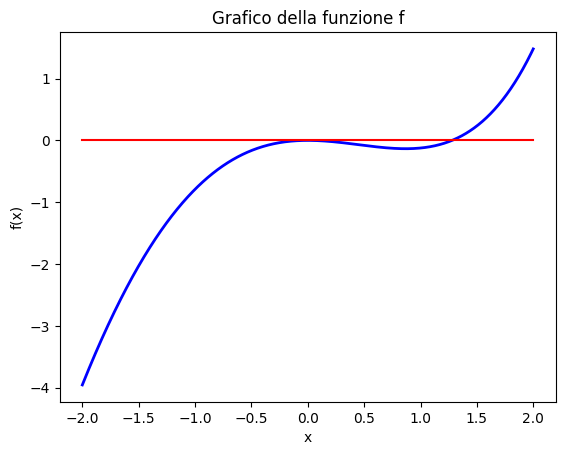

In [18]:
# rappresentazione grafica della funzione f
xgrid=np.linspace(-2,2,1000)
plt.plot(xgrid, f(xgrid), 'b-', linewidth=2.0)
plt.plot(xgrid, np.zeros(np.shape(xgrid)), 'r')
plt.title("Grafico della funzione f")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.show()

# **Bisezione**


<mark>**Domanda:**</mark></br>
 Il metodo di bisezione è applicabile per calcolare
entrambe le radici? Motivare la risposta.



<mark>**Esercizio 1.1: implementazione bisezione**</mark></br>

Scrivere una function $\verb|bisez|$ che implementi il metodo di bisezione. L'intestazione della funzione sarà ad esempio la seguente:


      def bisez(f,a,b,toll):
      #
      # implementazione di bisezione
      #
      return xvect


Tale funzione riceve in input:
* $\verb|f|→$ funzione di cui vogliamo calcolare gli zeri,
* $a→$ primo estremo
* $b→$ secondo estremo
* $\verb|toll|→$ tolleranza richiesta

e in out
* $\verb|xvect|→$ il vettore delle iterate.




In [ ]:
# definzione del metodo di bisezione
def bisez(f, a, b, toll):
  if(f(a)*f(b)>=0):
    raise RuntimeError("Errore: a e b non è una bracket") #faccio un controllo sull'intervallo iniziale: eseguo il codice/la
  #funzione solo se la funzione assume segno opposto agli estremi dell'intervallo


  xvect=[]
  while(abs(b-a)>toll):
    #calcolo il punto medio
    x=0.5(a+b)
    if(f(x)==0):
      xvect.append(x)
      print("x è uno zero")
      break
    

    if(f(x)*f(a)>0):
      a=x
    else:
      b=x
    xvect.append(x)
  
  return np.array(xvect)

<>:10: SyntaxWarning: 'float' object is not callable; perhaps you missed a comma?
<>:10: SyntaxWarning: 'float' object is not callable; perhaps you missed a comma?
/tmp/ipykernel_11749/4209406612.py:10: SyntaxWarning: 'float' object is not callable; perhaps you missed a comma?
  x=0.5(a+b)


<mark>**Esercizio 1.2**</mark></br>
Quando è possibile, applicare il metodo di bisezione alla funzione $f$.
Stampare il numero di iterazioni, lo zero trovato $x^*$ e il valore della funzione $f(x^*)$.

In [ ]:
# scelta degli estremi a,b
a,b=1, 1.5


xvect = bisez(f, a, b, 1e-12)

# stampare il numero di iterazioni effettuato, il valore di x0 e valore di f(x0)
print("Numero iterazioni: %d." %len(xvect))
print("Ultimo valore di x: %f" % x0)
print("Ultimo valore di f: %.e\n" % f(x0))

TypeError: 'float' object is not callable

**Alcuni commenti finali sul metodo di bisezione**

Dalla teoria sappiamo che:

*   Il metodo di bisezione è convergente e abbiamo una stima dell'errore (anche senza dover sapere la soluzione esatta)

\begin{equation}
|e^k| \le \frac{1}{2^{k+1}} |b-a| .
\end{equation}

*   Se voglio ottenere una soluzione esatta a meno di una tolleranza $eps$

\begin{equation}
k > \log_2 \frac{|b-a|}{eps} - 1 .
\end{equation}

*   La convergenza del metodo di bisezione è lenta (l'errore non sempre decresce monotonicamente).

*   Se uno zero ha molteplicità dispari, allora vale il teorema degli zeri. Nel caso di molteplicità pari, non è garantito.

# **Metodo di Newton**

<mark>**Domanda:**</mark></br>
Discutere le proprietà  di convergenza del metodo di Newton per
  entrambi gli zeri, valutando l'opportunità  di applicare il metodo
  di Newton.





<mark>**Esercizio 2.1: implementazione Newton**</mark></br>
Scrivere una function $\verb|newton|$ che implementi il metodo di Newton. L'intestazione della funzione sarà ad esempio la seguente:


      def newton (f,df,x0,nmax,toll)
      #
      # implementazione del metodo di newton
      #
      return xvect

Tale funzione riceve in input:
* $\verb|f|→$ funzione di cui vogliamo calcolare gli zeri,
* $\verb|df|→$ la derivata della funzione $f$,
* $x_0→$ punto di partenza
* $\verb|nmax|→$ numero massimo di iterazione
* $\verb|toll|→$ tolleranza richiesta

e in out
* $\verb|xvect|→$ il vettore delle iterate.

Si utilizzi un criterio d'arresto basato sul modulo della differenza tra due iterate successive.


In [ ]:
# definizione del metodo di newton
def newton(f, df, x0, nmax, toll):


  # inizializzazione del vettore delle iterazioni
  xvect=[]
  xold=x0
  # ciclo iterativo
  for nit in range(nmax):
    if(df(xold)==0):
      raise RuntimeError("la derivata prima nel punto xold è uguale a zero")
    
    # passo iterativo
    xnew=xold-f(xold)/df(xold)
    
  
    # carico i vettori
    xvect.append(xnew)
    # criterio di arresto e aggiornamento 
    if(abs(xnew-xold)<toll):
      break
    else:
      xold=xnew #aggiorno la variabile xold del metodo iterativo


  return xvect

<mark>**Esercizio 2.2: modifica di Newton**</mark></br>
Si scriva, modificando opportunamente la function $\verb|newton|$,
il metodo di Newton modificato, passando come parametro in ingresso anche la molteplicità dello zero cercato. L'intestazione della funzione sarà la seguente:


      def newton (f,df,x0,nmax,toll,m=1)
        #
        # modificare il passo iteratativo di newton
        #  x^{k+1} = x^k - m f(x^k)/f'(x^k)
        #
        return xvect

dove $\verb|m|$ è la molteplicità dello zero cercato.


In [34]:
# definizione del metodo di newton modificato
def newton(f, df, x0, nmax, toll, m=1):


  # inizializzazione del vettore delle iterazioni
  xvect=[]
  xold=x0
  # ciclo iterativo
  for nit in range(nmax):
    if(df(xold)==0):
      raise RuntimeError("la derivata prima nel punto xold è uguale a zero")
    
    # passo iterativo
    xnew=xold-m*f(xold)/df(xold)
    
  
    # carico i vettori
    xvect.append(xnew)
    # criterio di arresto e aggiornamento 
    if(abs(xnew-xold)<toll):
      break
    else:
      xold=xnew #aggiorno la variabile xold del metodo iterativo


  return np.array(xvect)

<mark>**Esercizio 2.3**</mark></br>

Applicare il metodo di Newton e, quando è il caso, il metodo di Newton modificato (aggiungendo la specifica $\verb|m|$) con tolleranza $10^{-6}$, per la funzione
\begin{equation}
f(x):=e^{x}-x^{2}-\textrm{sin}(x)-1,\qquad x\in[-2,2]\;.
\end{equation}
Riportare su un grafico in scala semilogaritmica l'andamento dell'errore in funzione del numero di iterazioni. Per il calcolo dell'errore si assuma come valore esatto dello zero non nullo, il valore $x=1.279701331000996$. Cosa si osserva nell'ordine di convergenza?


In [36]:
# funzione f e la sua derivata df
f = lambda t: np.exp(t) - t**2 - np.sin(t) - 1.0
df = lambda t: np.exp(t) - 2*t - np.cos(t)

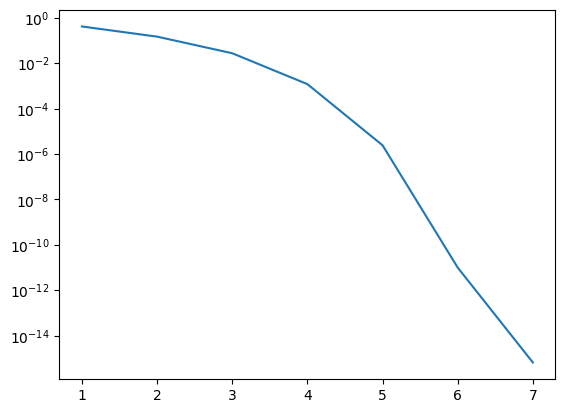

In [40]:
# ricerca dello zero xe=1.279701331000996
xe=1.279701331000996
# starting point
x0=1

xvect=newton(f,df,x0,100,1e-6)
    
# calcolo dell'errore
error=np.abs(xe-xvect)
# rappresentazione grafica dell'errore usando plt.semilogy()
plt.semilogy(np.arange(1,len(xvect)+1), error)
plt.show()

In [13]:
# Ricerca dello zero xe=0
xe=0
# starting point
x0=0.1




**Alcuni commenti finali sul metodo di Newton**

Dalla teoria sappiamo che:

*   Il metodo di Newton è (SOLO) localmente convergente
*   Se converge, allora converge quadraticamente per zeri di molteplicità 1, linearmente per zeri di molteplicità superiore (in tal caso occorre Newton modificato per ripristinare convergenza ottimale)
*   Il metodo di Newton è un particolare metodo di punto fisso

# **Esercizi per casa**


## **Metodo punto fisso**

Si consideri il problema della ricerca degli zeri dell'equazione non lineare $g(x)=0$, dove $g$ è definita da:
\begin{equation}
g(x):= 4x-e^{x^2},\qquad x\in\left[0,\frac{3}{2}\right]\;.
\end{equation}


<mark>**Esercizio 3.1**</mark></br>
Disegnare il grafico della funzione $g$ e la retta $y=0$ in modo
da evidenziare le due soluzioni dell'equazione. Inoltre, per ogni soluzione, determinare un opportuno intervallo che la contenga.

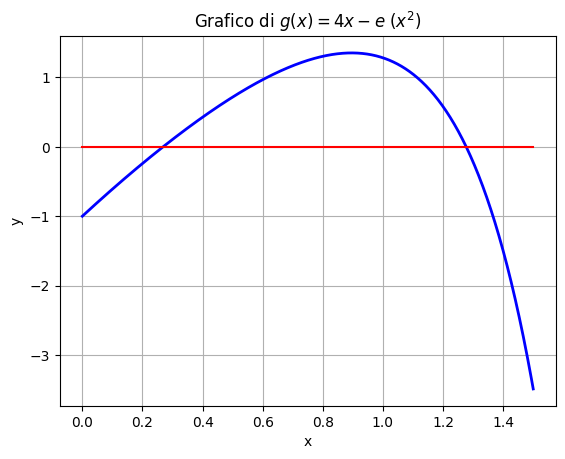

In [26]:
# plot della funzione g
g=lambda x:4*x-np.exp(x**2)

xgrid=np.linspace(0,1.5,1000)
plt.plot(xgrid, g(xgrid), "b-", linewidth=2.0)
plt.plot(xgrid, np.zeros(np.shape(xgrid)), "r-")
plt.title("Grafico di $g(x)=4x-e^ (x^2)$")
plt.xlabel("x")
plt.ylabel("y")
plt.grid()
plt.show()

**Osservazione sulle soluzioni dell'esercizio 3.1:**

<mark>**Esercizio 3.2**</mark></br>
Individuare la funzione di iterazione $\phi$ per il metodo di punto fisso e la sua derivata $\phi'(x)$. Plottare $\phi'$ nell'intervallo considerato. Il metodo di punto fisso è applicabile per calcolare
entrambe le radici? Motivare la risposta.

In [15]:
# plot della derivata prima di phi

**Motivazione esercizio 3.2:**

<mark>**Esercizio 3.3**</mark></br>

Scrivere la function $\verb|puntofisso|$ che implementi il metodo di punto fisso. L'intestazione della funzione sarà ad esempio la seguente:


      def puntofisso (phi,x0,nmax,toll)
        #
        # implementazione del metodo di newton
        #
        return xvect

Tale funzione riceve in input:
* $\verb|phi|→$ funzione di iterazione,
* $x_0→$ punto di partenza
* $\verb|nmax|→$ numero massimo di iterazione
* $\verb|toll|→$ tolleranza richiesta

e in out
* $\verb|xvect|→$ il vettore delle iterate.

Si utilizzi un criterio d'arresto basato sul modulo della differenza tra due iterate successive.

In [7]:
def puntofisso(phi, x0, nmax, toll):

  #inizializzazione
  xvect=[]
  xold=x0

  for i in range(nmax):
    #calcolo il nuovo punto
    xnew=phi(xold)
    #carico i vettori
    xvect.append(xnew)

    #criterio di arresto e aggiorno
    if(abs(xnew-xold)<toll):
      break
    else:
      xold=xnew

  return np.array(xvect)

<mark>**Esercizio 3.3**</mark></br>
Applicare il metodo del punto fisso, quando possibile, con numero massimo di iterazioni $\verb|nmax|=100$ e tolleranza pari a
$10^{-5}$, utilizzando la funzione $\verb|puntofisso|$ e dati iniziali $x0=0$, $x0=1.5$.

In [4]:
import numpy as np
import matplotlib.pyplot as plt

In [8]:
# verifica del metodo di punto fisso
nmax=100
toll=1e-5

for x0 in [0, 1.5]:
    xvect=puntofisso(phi, x0, nmax, toll)
    print("Dato iniziale x0=%.1f" %x0)
    print("Numero di iterazione: %d" %len(xvect))
    print("Radice trovata: %f\n" %xvect[-1])

NameError: name 'phi' is not defined

## **Bisezione**

<mark>**Esercizio 4.1**</mark></br>
Si consideri il problema della ricerca degli zeri dell'equazione non
lineare $f(x)=0$, dove $f$ è definita da:
\begin{equation}
f(x):=e^{x}-x^{2}-\textrm{sin}(x)-1,\qquad x\in[-2,2]\;.
\end{equation}

Provare ad implementare bisezione con il ciclo for. Ricordo che il numero massimo di iterazioni è
\begin{equation}
 k > \log_2(\frac{|b-a|}{\text{toll}}) -1
\end{equation}
con $k$ un numero intero. Ricordo che nel caso in cui si ottenga un numero non intero nell'espressione a destra allora $k$ va arrotondato al numero intero superiore. Un comando utile per il calcolo di $k$ è $\verb|np.fix|$ (si veda $\verb|help(np.fix)|$).



In [12]:
def bisezfor(f, a, b, toll):
  #controllo se gli estremi costituiscono una bracket
  if(f(a)*f(b)>=0):
    raise RuntimeError("ERRORE: l'intervallo [a,b] non è una bracket")
  
  #inizializzazione
  nmax=np.fix(np.log2(abs(b-a)/toll)-1)+1
  xvect=[]

  for i in range(int(nmax)):
    x=0.5*(a+b)
    #primo controllo se x è uno zero
    if(f(x)==0):
      xvect.append(x)
      print("x è esattamente uno zero della funzione")
      break

    #metodo di bisezione
    if(f(a)*f(b)>0):
      a=x
    else:
      b=x
    xvect.append(x)
  
  return np.array(xvect)

<mark>**Esercizio 4.2**</mark></br>
Testare la function $\verb|bisezfor|$ nella ricerca degli zeri della funzione $f$.

In [13]:
f = lambda x: np.exp(x) - x**2 - np.sin(x) - 1.0
# scelta degli estremi a,b
a,b=1, 1.5
xvect=bisezfor(f, a, b, toll=1e-12)

x0=xvect[-1]

# stampare iterazioni, valore di x* e valore di f(x*)
print("Numero iterazioni: %d" %len(xvect))
print("Ultimo valore di x: %f" %x0)
print("Ultimo valore di f: %.e\n" %f(x0))



Numero iterazioni: 38
Ultimo valore di x: 1.250000
Ultimo valore di f: -2e-02



## **Bisezione e Newton**
<mark>**Esercizio 5**</mark></br>
Si consideri il problema della ricerca degli zeri dell'equazione non
lineare $f(x)=0$, dove $f$ è definita da:
\begin{equation}
f(x):=e^{x}-x^{2}-\textrm{sin}(x)-1,\qquad x\in[-2,2]\;.
\end{equation}
Utilizzare in sequenza il metodo di bisezione e il metodo di Newton per la ricerca dello zero $1 < \alpha_2 < 1.5$; in particolare si adotti il metodo di bisezione per l'avvicinamento allo zero e successivamente il metodo di Newton per la
convergenza "veloce" ad $\alpha_2$, assumendo come punto di innesco lo zero approssimato con il metodo di bisezione. Nello specifico si considerino 5 iterazioni del metodo di bisezione sull'intervallo $[1, 1.5]$ e si assuma come tolleranza per il metodo di Newton il valore $10^{-10}$.



In [14]:
# estremi dell'intervallo
a=1
b=1.5
f = lambda x: np.exp(x) - x**2 - np.sin(x) - 1.0
df = lambda x: np.exp(x) - 2*x - np.cos(x)

nmax=5
toll_b=1.e-3
nmax_n=100
toll_n=1e-10

xvect_b=bisez(f, a, b, toll_b)
xvect_n=newton(f, df, xvect_n[nmax-1], nmax_n, toll_n)

xvect=np.concatenate([xvect_b[0:nmax], xvect_n])

x=xvect[-1]


print("Numero iterazioni: %d" %len(xvect))
print("Ultimo valore di x: %1.10f" %x)
print("Ultimo valore di f: %.e\n" %f(x0))


NameError: name 'bisez' is not defined

In [1]:
#prova dei vari comandi
#Liste e tuple
L=[1,2,5,"ciao",4,10,"anna"]
print(L)

[1, 2, 5, 'ciao', 4, 10, 'anna']


In [2]:
L[0]

1

In [3]:
L[-1]

'anna'

In [4]:
P=[3,7]
L+P

[1, 2, 5, 'ciao', 4, 10, 'anna', 3, 7]

In [5]:
2*L

[1, 2, 5, 'ciao', 4, 10, 'anna', 1, 2, 5, 'ciao', 4, 10, 'anna']

In [6]:
len(L)

7

In [7]:
L.append(-5)

In [8]:
L

[1, 2, 5, 'ciao', 4, 10, 'anna', -5]

In [9]:
T=(5,6,3)
T[1]

6

In [10]:
x=3
y=4
T=x+y, 7*x
T

(7, 21)

In [11]:
a,b=x+y, 7*x
print(a)

7


In [12]:
print(b)

21


In [14]:
def areaRettangolo(base, altezza):
    return base*altezza
areaRettangolo(3,5)

15

In [16]:
def perimetroTriangoloRett(cateto1, cateto2):
    ipotenusa=(cateto1**2+cateto2**2)**0.5
    perimetro=cateto1+cateto2+ipotenusa
    return perimetro
x=3.0
y=4.0
perimetroTriangoloRett(x,y)

12.0

In [17]:
#esercizio1
def padding(L,n):
    return L+n*[0]
L=[1,3,"ciao",8]
n=5
padding(L,n)

[1, 3, 'ciao', 8, 0, 0, 0, 0, 0]

In [21]:
z=1
for i in range(5):
    z=2*z
    print("Adesso siamo al ciclo i=%d, e z vale %d", (i, z))
print("Adesso abbiamo finito. Ora z=%d." %z)

Adesso siamo al ciclo i=%d, e z vale %d (0, 2)
Adesso siamo al ciclo i=%d, e z vale %d (1, 4)
Adesso siamo al ciclo i=%d, e z vale %d (2, 8)
Adesso siamo al ciclo i=%d, e z vale %d (3, 16)
Adesso siamo al ciclo i=%d, e z vale %d (4, 32)
Adesso abbiamo finito. Ora z=32.


In [22]:
x=5
while(x>0):
    x=x-2
    print("x è ancora positivo: tolgo 2 e ricontrollo")
print("\nFatto!")


x è ancora positivo: tolgo 2 e ricontrollo
x è ancora positivo: tolgo 2 e ricontrollo
x è ancora positivo: tolgo 2 e ricontrollo

Fatto!


In [24]:
x=5
y=3
if(x>y):
    print("x è maggiore di y")
else:
    print("x è minore o uguale ad y")

x è maggiore di y


In [25]:
#esercizio 2
def ReLU(x):
    if(x>=0.0):
        return x
    else:
        return 0


In [27]:
#esercizio 3
def media(L):
    totale=0
    for valore in L:
        totale=totale+valore
    risultato=totale/len(L)
    return risultato

#oppure, usando le funzioni già implementate in python
def media(L):
    return sum(L)/len(L)
    

In [28]:
#esercizio 4
eps=1
while(1+eps!=1):
    eps=eps/2.0
eps=2.0*eps
print(eps)

2.220446049250313e-16


In [29]:
import numpy as np

In [30]:
np.linspace(0,1,5)

array([0.  , 0.25, 0.5 , 0.75, 1.  ])

In [31]:
g=np.linspace(0,1,5)

In [32]:
print(g[0])
print(g[2])


0.0
0.5


In [37]:
g[1:4]
g[1:]
g[:-2]
g[[1,4,0]]

array([0.25, 1.  , 0.  ])

In [38]:
x=np.array([1,4,5,-2,1,0])
y=np.linspace(-1,1,6)
z=np.array([1,-2])

In [39]:
print(y)
print(x+y)
print(x*y)

[-1.  -0.6 -0.2  0.2  0.6  1. ]
[ 0.   3.4  4.8 -1.8  1.6  1. ]
[-1.  -2.4 -1.  -0.4  0.6  0. ]


In [40]:
print(z)
print(2.0*z)
print(z+5.0)
print(z**2.0)

[ 1 -2]
[ 2. -4.]
[6. 3.]
[1. 4.]


In [41]:
np.zeros((2,3))

array([[0., 0., 0.],
       [0., 0., 0.]])

In [42]:
np.ones((2,3))

array([[1., 1., 1.],
       [1., 1., 1.]])

In [43]:
np.arange(3,8)

array([3, 4, 5, 6, 7])

In [44]:
np.diag([1,2,5])

array([[1, 0, 0],
       [0, 2, 0],
       [0, 0, 5]])

In [45]:
C=np.array([[1,1],
            [4,5]])

In [46]:
np.diag(C)

array([1, 5])

In [47]:
np.eye(3)

array([[1., 0., 0.],
       [0., 1., 0.],
       [0., 0., 1.]])

In [48]:
x=np.array([1.0, 3.0])
np.sin(x)

array([0.84147098, 0.14112001])

In [49]:
np.cos(x)

array([ 0.54030231, -0.9899925 ])

In [50]:
np.tan(x)

array([ 1.55740772, -0.14254654])

In [51]:
np.exp(x)

array([ 2.71828183, 20.08553692])

In [52]:
np.log(x)

array([0.        , 1.09861229])

In [53]:
np.pi

3.141592653589793

In [55]:
#esercizio 5
A0=np.diag([1,2,5])
A1=np.zeros((1,3))
A2=8*np.ones((2,3))
A12=np.block([[A1],
              [A2]])
A=np.block([A0,A12])
A

array([[1., 0., 0., 0., 0., 0.],
       [0., 2., 0., 8., 8., 8.],
       [0., 0., 5., 8., 8., 8.]])

In [57]:
#esercizio 6
def H(n):
    return np.arange(1, n**2+1).reshape((n,n))
H(3)

array([[1, 2, 3],
       [4, 5, 6],
       [7, 8, 9]])

In [59]:
#esercizio 7
def MatPot(A,n):
    d=A.shape[0] #dimensione di A (assumendo sia quadrata)
    B=np.eye(d)
    for i in range(n):
        B=B@A
    return B
Z=np.array([[0,1],
            [-1,0]])
MatPot(Z,2)


array([[-1.,  0.],
       [ 0., -1.]])

In [60]:
#GRAFICI CON MATPLOTLIB
import matplotlib.pyplot as plt

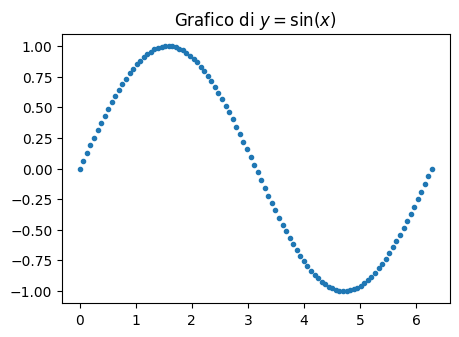

In [61]:
x=np.linspace(0,2*np.pi,100)
y=np.sin(x)
plt.figure(figsize=(5, 3.5))
plt.plot(x,y,".")
plt.title("Grafico di $y=\\sin(x)$")
plt.show()

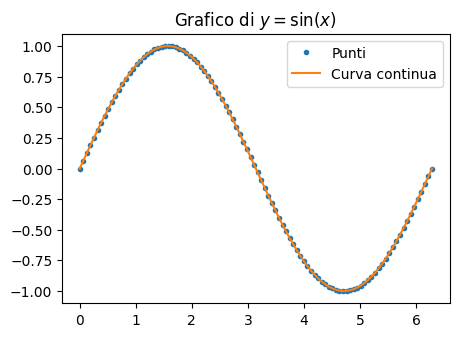

In [62]:
plt.figure(figsize=(5, 3.5))
plt.plot(x,y,'.', label="Punti")
plt.plot(x,y,label="Curva continua")
plt.title("Grafico di $y=\\sin(x)$")
plt.legend()
plt.show()


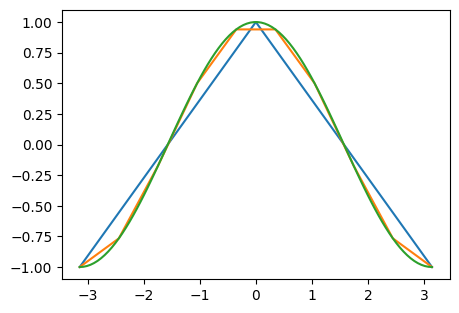

In [64]:
#esercizio 8
plt.figure(figsize=(5, 3.5))
for N in[5,10,100]:
    x=np.linspace(-np.pi, np.pi, N)
    plt.plot(x, np.cos(x))
   


In [2]:
#EQUAZIONI NON LINEARI
import numpy as np
import matplotlib.pyplot as plt


In [5]:
f=lambda t:np.sin(t*np.pi)
g=lambda x:np.sin(x*np.pi)
h=lambda x, y, z: x+2*y+2*z
print("valuto la funzione f in 0.5: %f" %f(0.5))
print("valuto la funzione g in 0.5: %f" %g(0.5))
print("valuto la funzione h in (1,2,3): %f" %h(1,2,3))

valuto la funzione f in 0.5: 1.000000
valuto la funzione g in 0.5: 1.000000
valuto la funzione h in (1,2,3): 11.000000


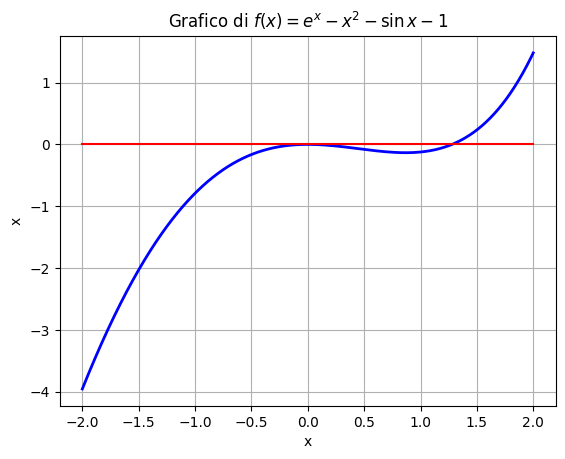

In [ ]:
f=lambda x:np.exp(x)-x**2-np.sin(x)-1.0
xgrid=np.linspace(-2,2,1000)
plt.plot(xgrid, f(xgrid), "b-", linewidth=2.0)
plt.plot(xgrid, np.zeros(np.shape(xgrid)), "r-")
plt.title("Grafico di $f(x)=e^x-x^2-\\sin x-1$")
plt.xlabel("x")
plt.ylabel("y")
plt.grid()
plt.show()

In [7]:
#Bisezione
#Esercizio 1.1 implementazione bisezione
def bisez(f,a,b,toll=1e-16):
    if (f(a)*f(b)>=0):
        raise RuntimeError("ERRORE: l'intervallo [a,b] non è un bracket")
    xvect=[]
    while (abs(b-a)>toll):
        #calcolo del punto medio
        x=0.5*(a+b)
        #primo controllo se x è uno zero
        if (f(x)==0):
            xvect.append(x)
            print("x è esattamente uno zero della funzione")
            break

        #metodo di bisezione
        if (f(a)*f(x)>0):
            a=x
        else:
            b=x
        xvect.append(x)
    return np.array(xvect)

In [ ]:
#Esercizio 1.2
#scelta estremi a,b della bracket
a,b=1, 1.5
xvect=bisez(f,a,b,1e-12)
x0=xvect[-1]
print("numero di iterazioni: %d." %len(xvect))
print("Ultimo valore di x: %f" %x0)
print("Ultimo valore di f: %.e\n" %f(x0))


numero di iterazioni: 39.
Ultimo valore di x: 1.279701
Ultimo valore di f: 7e-13



In [9]:
#Metodo di Newton
#Esercizio 2.1
def newton(f,df,x0,nmax=100,toll=1e-16, m=1):
    xvect=[]
    xold=x0

    for nit in range(nmax):
        if(df(xold)==0):
            raise RuntimeError("ERRORE: derivata prima nulla\n")
        else:
            xnew=xold-m*f(xold)/df(xold)
            xvect.append(xnew)
        if(abs(xnew-xold)<toll):
            break
        else:
            xold=xnew
    return np.array(xvect)



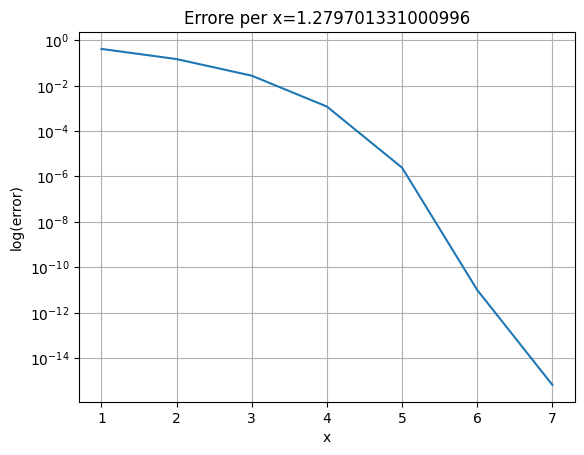

In [11]:
def f(t): return np.exp(t)-t**2-np.sin(t)-1.0
def df(t): return np.exp(t)-2*t-np.cos(t)
xe=1.279701331000996
x0=1
xvect=newton(f,df,x0,100,1e-6)
error=np.abs(xe-xvect)

#rappresentazione grafica dell'errore
plt.semilogy(np.arange(1,len(xvect)+1), error)
plt.title("Errore per x=%.15f" %xe)
plt.xlabel("x")
plt.ylabel("log(error)")
plt.grid()
plt.show()


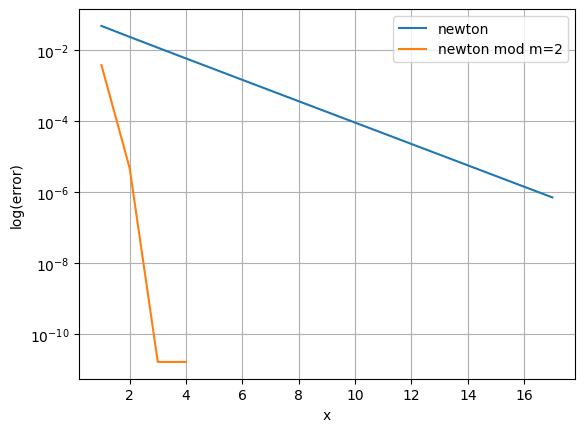

In [12]:
#Ricerca dello zero xe=0
xe=0
#starting point
x0=0.1
xvect_n=newton(f,df,x0,100,1e-6)
error_n=np.abs(xe-xvect_n)
xvect_nm=newton(f,df,x0,100,1e-6,m=2)
error_nm=np.abs(xe-xvect_nm)
plt.semilogy(np.arange(1,len(xvect_n)+1), error_n)
plt.semilogy(np.arange(1,len(xvect_nm)+1), error_nm)
plt.legend(['newton', 'newton mod m=2'])
plt.xlabel('x')
plt.ylabel('log(error)')
plt.grid()
plt.show()



In [1]:
#esercizio punto fisso
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def g(x): return 4*x-np.exp(x**2)
x=np.linspace(0, 1.5, 1000)

/tmp/ipykernel_1126/119598407.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


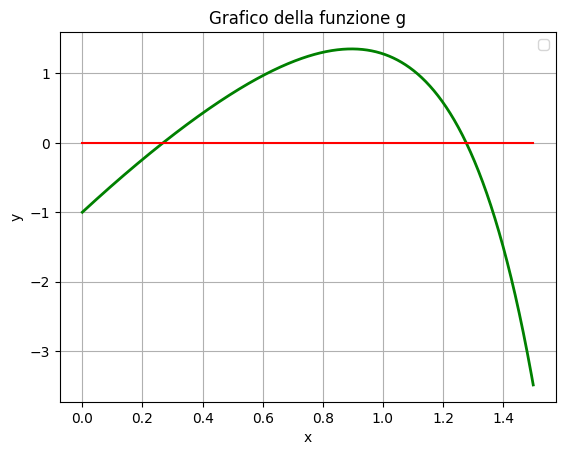

In [ ]:
#plot funzione g
plt.plot(x, g(x), '-g', linewidth=2)
plt.plot([0, 1.5], [0, 0], '-r') #per plottare asse y, così da realizzare ricerca grafica degli zeri
plt.title("Grafico della funzione g")
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.grid("major")
plt.show()

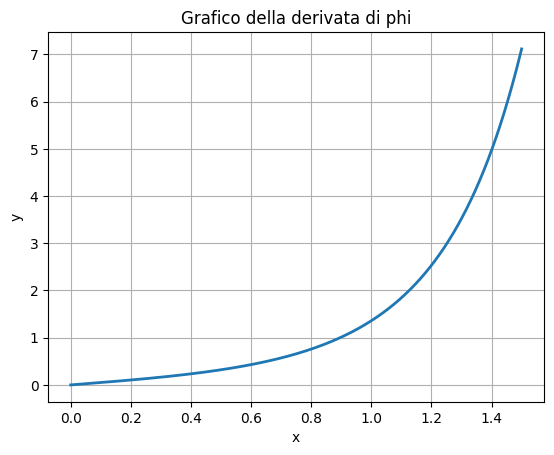

In [4]:
#es 3.2
def phi(t): return np.exp(t**2)/4
def dphi(t): return t*np.exp(t**2)/2

plt.plot(x, dphi(x), linewidth=2)
plt.title("Grafico della derivata di phi")
plt.xlabel("x")
plt.ylabel("y")
plt.grid()
plt.show()

In [ ]:
#esercizio 3.3
